In [44]:
import os
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from typing import TypedDict,Annotated
import operator

In [45]:
load_dotenv()

True

In [46]:
try:
    api_key=os.getenv('api_key')
    api_key2=os.getenv('GEMINI_API_KEY2')
    api_key3=os.getenv('GROQ_API_KEY')
    
except Exception as e:
    print('Error is',e)


In [47]:
model=ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite',api_key=os.getenv('api_key'))
#model=ChatGroq(model='openai/gpt-oss-120b',api_key=api_key3,max_tokens=999)

In [48]:
class EvaluationSchema(BaseModel):
    feedback:str=Field(description="Detail Feedback for the essay")
    score:int=Field(description="Score out of 10",ge=0,le=10)

In [49]:
structured_model=model.with_structured_output(EvaluationSchema)

In [50]:
essay="""
Artificial intelligence is rapidly reshaping various sectors in Nepal, offering innovative solutions to long-standing developmental challenges. In agriculture, which forms the backbone of the country's economy, AI-driven applications and machine learning models are helping farmers analyze soil health, predict weather patterns, and optimize crop yields despite difficult topography. Furthermore, the burgeoning tech ecosystem in Kathmandu and other major hubs is embracing automation and data analytics, enabling local startups and IT enterprises to build scalable software solutions that compete globally.

In the education and public service sectors, AI holds immense potential to bridge resource gaps and improve accessibility. Intelligent tutoring systems and language-processing tools are being adapted to support multilingual learning environments, making educational content more inclusive for students across diverse ethnic and regional backgrounds. Additionally, government and non-profit organizations are beginning to leverage predictive analytics for disaster risk management—a critical application in a geographically vulnerable nation prone to monsoon floods and earthquakes.

However, realizing the full benefits of artificial intelligence in Nepal requires addressing structural hurdles, such as limited digital infrastructure, unreliable power supply, and a shortage of specialized technical training outside major cities. To ensure sustainable growth, policymakers, academic institutions, and industry leaders must collaborate on digital literacy initiatives and ethical frameworks. By fostering local innovation and responsible adoption, Nepal can harness AI not just as a foreign trend, but as a tailored tool for national progress.
"""

In [51]:
class Essaystate(TypedDict):
    
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    avg_score:float

In [52]:
def clarity_of_thought(state:Essaystate):
    prompt=f"Evalaute the clarity of thought of the followinng essay and Provide a feedback and assign a score out of 10 \n {state['essay']}"
    output=structured_model.invoke(prompt)
        
    return {'clarity_feedback':output.feedback,'individual_scores':[output.score]}

In [53]:
def depth_of_analysis(state:Essaystate):
    prompt=f"Evalaute the depth of analysis of the followinng essay and Provide a feedback and assign a score out of 10 \n {state['essay']}"
    output=structured_model.invoke(prompt)
        
    return {'analysis_feedback':output.feedback,'individual_scores':[output.score]}

In [54]:
def evaluate_language(state:Essaystate):
    prompt=f"Evalaute the quality of the followinng essay and Provide a feedback and assign a score out of 10 \n {state['essay']}"
    output=structured_model.invoke(prompt)
    
    return {'language_feedback':output.feedback,'individual_scores':[output.score]}

In [55]:
def final_evalauation(state:Essaystate):
    
    #summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback=model.invoke(prompt).content
    
    #avg calculate
    avg_score=sum(state['individual_scores'])/len(state["individual_scores"])
    
    return {'overall_feedback':overall_feedback,'avg_score':avg_score}
    
    

In [56]:
graph=StateGraph(Essaystate)

graph.add_node('clarity_of_thought',clarity_of_thought)
graph.add_node('depth_of_analysis',depth_of_analysis)
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('final_evalauation',final_evalauation)

graph.add_edge(START,'clarity_of_thought')
graph.add_edge(START,'depth_of_analysis')
graph.add_edge(START,'evaluate_language')

graph.add_edge('clarity_of_thought','final_evalauation')
graph.add_edge('depth_of_analysis','final_evalauation')
graph.add_edge('evaluate_language','final_evalauation')


graph.add_edge('final_evalauation',END)


workflow=graph.compile()

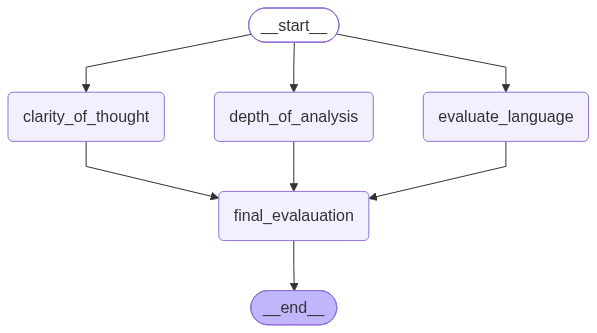

In [57]:
workflow

In [58]:
initial_state={
    'essay':essay
}
final_result=workflow.invoke(initial_state)

In [59]:
final_result

{'essay': "\nArtificial intelligence is rapidly reshaping various sectors in Nepal, offering innovative solutions to long-standing developmental challenges. In agriculture, which forms the backbone of the country's economy, AI-driven applications and machine learning models are helping farmers analyze soil health, predict weather patterns, and optimize crop yields despite difficult topography. Furthermore, the burgeoning tech ecosystem in Kathmandu and other major hubs is embracing automation and data analytics, enabling local startups and IT enterprises to build scalable software solutions that compete globally.\n\nIn the education and public service sectors, AI holds immense potential to bridge resource gaps and improve accessibility. Intelligent tutoring systems and language-processing tools are being adapted to support multilingual learning environments, making educational content more inclusive for students across diverse ethnic and regional backgrounds. Additionally, government a

In [64]:
print(final_result['overall_feedback'][0]['text'])

Here is a summarized version of the feedback:

**Summary of Feedback**

Your essay is well-structured, coherent, and demonstrates a strong understanding of AI’s potential in Nepal, particularly within the sectors of agriculture, education, and disaster management. Your writing is professional and logically organized, effectively balancing the discussion of benefits with an awareness of local structural constraints.

**Areas for Improvement:**
*   **Practical Application:** To strengthen your arguments, incorporate concrete case studies or examples of Nepali startups and AI initiatives currently in operation.
*   **Analytical Depth:** Move beyond a general overview by providing a more critical analysis. Specifically, explore the mechanisms of implementation, the socioeconomic impacts, and how local challenges—such as the digital divide and linguistic diversity—influence the development of AI models in Nepal.


In [61]:
final_result['avg_score']

8.333333333333334